# **Students Who Slip On Maths**

## Objectives

* Import the cleaned .csv file to a pandas dataframe for exploration

* Investigate xyz

* 



## Inputs

* The clean 'student_mat_cleaned.csv'  

* Libraires containing the tools needed, pandas, numpy, matplotlib, seaborn. 

## Outputs

* Visualisations 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\NateM\\Desktop\\CI_DA\\Capstone_Three\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\NateM\\Desktop\\CI_DA\\Capstone_Three'

# Import block

In [4]:
# Libraries needed 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns




---

# Section 1 - Load

Load the cleaned .csv into a pandas dataframe

In [5]:
# Load the raw data
df_cleaned = pd.read_csv("Dataset/Cleaned/student_mat_cleaned.csv")

# View the dataframe
df_cleaned.head(5)

,school,age,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,studytime_label
0,GP,18,course,mother,2,2,0,yes,no,no,...,3,4,1,1,3,6,5,6,6,2 - 5 hours
1,GP,17,course,father,1,2,0,no,yes,no,...,3,3,1,1,3,4,5,5,6,2 - 5 hours
2,GP,15,other,mother,1,2,3,yes,no,yes,...,3,2,2,3,3,10,7,8,10,2 - 5 hours
3,GP,15,home,mother,1,3,0,no,yes,yes,...,2,2,1,1,5,2,15,14,15,5 - 10 hours
4,GP,16,home,father,1,2,0,no,yes,yes,...,3,2,1,2,5,4,6,10,10,2 - 5 hours


---

# Section 2 - EDA

We'll first look at the main target which is the final mathematics grade (G3)

In [6]:
# Looping through methods for simpler output
methods = ["count", "mean", "median", "std", "min", "max"]

for aggregation in methods:
    print(f"Final Grade {aggregation.capitalize()}: {df_cleaned['G3'].agg(aggregation)}")

# View the quartile ranges
df_cleaned["G3"].describe()

Final Grade Count: 395
Final Grade Mean: 10.415189873417722
Final Grade Median: 11.0
Final Grade Std: 4.5814426109978434
Final Grade Min: 0
Final Grade Max: 20


count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

Here we see that on average out of 395 students, they're acheiving a mean final grade of 10.42 with a median of 11. With the mean being a touch lower than the median, it's a likely indication there are lower results poising a slight skew, which we will visualise shortly. 

Most of the students are acheiving between an 8 and 14 on their final grade. 

A standard deviation of 4.58 shows that there is a noticable variation in the performance across this range of students.

Now to visualise its distriution

In [7]:
# There is s bug with the matplotlib object, 
# requiring the cell to be run twice to get the visual output

# Method and format taken from Code Institues 
# 'Descriptive Statistics Topic 3: Variability' lesson notebook

fig, axes = plt.subplots(figsize=(8,5))
plt.title("Distribution of Final Grades", fontsize=15)
sns.histplot(
    data=df_cleaned,
    x="G3",
    kde=True
  )

plt.axvline(df_cleaned["G3"].mean(), color='r', linestyle='dashed', linewidth=2)
plt.text(x=df_cleaned["G3"].mean() + df_cleaned["G3"].std()/8 , y=axes.get_ylim()[1] * 0.90, s='Mean', fontsize=15, c='r')

fig.tight_layout()
plt.show()
plt.close(fig)


<Figure size 800x500 with 1 Axes>

We see our distrubution is focussed around the score of 10-11, with the bulk of the students are scoring between an 8 and and a 15. With no normal bell curve, and that clustering at 0, we know our distribution is non-normal so we'll be using non-parametric tests in the testing.

Now to look at studytime

In [8]:
# Display how many students fall into each studytime category
df_cleaned["studytime_label"].value_counts()

studytime_label
2 - 5 hours     198
< 2 hours       105
5 - 10 hours     65
> 10 hours       27
Name: count, dtype: int64

The majority of the students are studying between 2 and 5 hours a week, with the minority studying over 10 hours. It is unclear however if this is entirely dedicated to mathematics and so shouldn't be directly interpreted as more practice at mathematics.

Let's see how studytime and final grade (G3) sit together. 

In [12]:
df_cleaned.groupby("studytime").agg(
    student_count = ("G3", "count"),
    Mean_G3 = ("G3", "mean"),
    Median_G3 = ("G3", "median"),
    Std_G3 = ("G3", "std"),
    Min_G3 = ("G3", "min"),
    Max_G3 = ("G3", "max")
).round(2)


,student_count,Mean_G3,Median_G3,Std_G3,Min_G3,Max_G3
studytime,,,,,,
1,105,10.05,10.0,4.96,0,19
2,198,10.17,11.0,4.22,0,19
3,65,11.40,12.0,4.64,0,19
4,27,11.26,12.0,5.28,0,20


The final grade generally does tend to increase as students spend more time studying, shown by the mean steadily incrementing and then falling, as you move up through the bands, 10.05 for students studying less than 2 hours a week upto 11.40 for students studying between 5 and 10 hours, declining to 11.26 for those studying longer than 10 hours. 

You can see as well that the median is the same for those studying more than 10 hours as those studying upto 10 hrs. It also follows the same steady incrementation from the lower study times up to the 10 threshold. This suggests a likely positive relationship between increased studying time and a higher final grade but it's not wholely linear. Additionally, the categoeries themselves are unevely represented, more data could provide a more solid picture here.

Let's visualise it.

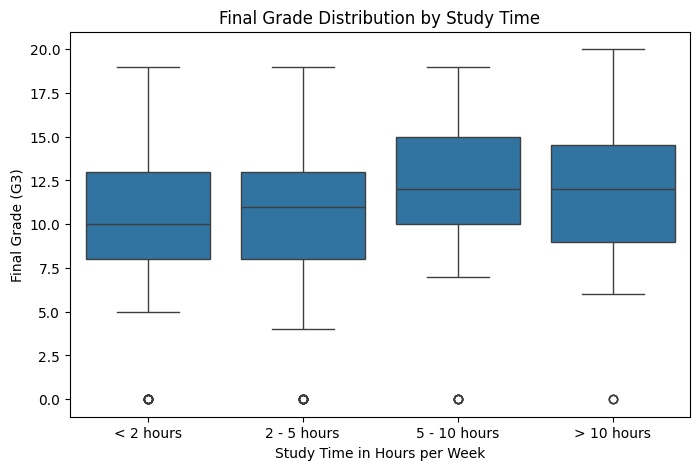

In [17]:
# Ordering for the plot
studytime_order = ["< 2 hours", "2 - 5 hours", "5 - 10 hours", "> 10 hours"]

# Make and view the plot
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_cleaned,
    x="studytime_label",
    y="G3",
    order = studytime_order
)

plt.title("Final Grade Distribution by Study Time")
plt.xlabel("Study Time in Hours per Week")
plt.ylabel("Final Grade (G3)")

plt.show()

Displayed by the boxplot is a positive leaning pattern of the increase in weekly study time increasing the grade score of a students final result. The median grade definitively increases from 10 at less than 2 hours of weekly study to 12 when studying over 5 hours. Despite this, we do have considerable overlap in the ranges of each grouping, with the performance increase plateauing at 10+ hours. Later statistical testing will provide the concrete answer. 

Now to look at the prior failures and if there is any affect on the final grade. Let's take a closer look the failures column. 

In [18]:
# Count of students with X failures 
df_cleaned["failures"].value_counts().sort_index()

failures
0    312
1     50
2     17
3     16
Name: count, dtype: int64

We see that the vast majority of the students have no prior fails. Let's have a look at it as a percentage count.

In [19]:
df_cleaned["failures"].value_counts(
    normalize=True
    ).sort_index().mul(100).round(2)

failures
0    78.99
1    12.66
2     4.30
3     4.05
Name: proportion, dtype: float64

We see that vast majority of students, 78.99%, are getting by with no failures. 

13%, only 50 students are receiving a single failure, with multiple failures taking up just over 4% each, 4.3 and 4.05 respectively, totalling at less than 20 students each, 17 and 16 students.    

In [ ]:
# Reused method from earlier to compare against final grade
df_cleaned.groupby("failures").agg(
    student_count = ("G3", "count"),
    Mean_G3 = ("G3", "mean"),
    Median_G3 = ("G3", "median"),
    Std_G3 = ("G3", "std"),
    Min_G3 = ("G3", "min"),
    Max_G3 = ("G3", "max")
).round(2)

,student_count,Mean_G3,Median_G3,Std_G3,Min_G3,Max_G3
failures,,,,,,
0,312,11.25,11.0,4.17,0,20
1,50,8.12,9.0,4.71,0,18
2,17,6.24,8.0,4.84,0,15
3,16,5.69,7.0,4.19,0,10


If we visualise it.

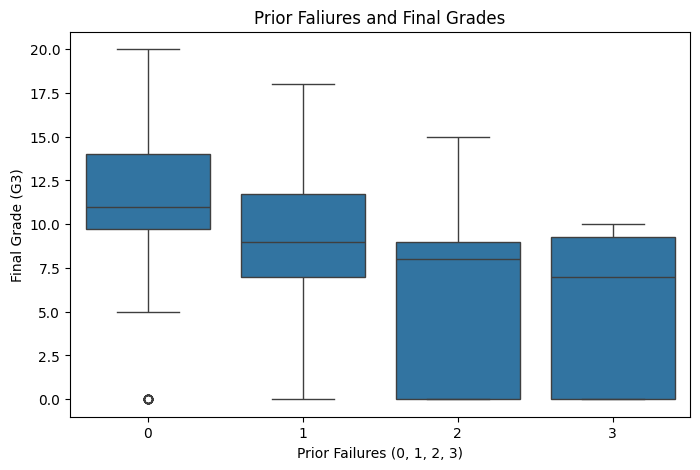

In [22]:
# Make and view the plot
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_cleaned,
    x="failures",
    y="G3"
)

plt.title("Prior Faliures and Final Grades")
plt.xlabel("Prior Failures (0, 1, 2, 3)")
plt.ylabel("Final Grade (G3)")

plt.show()

It's very apparent from the mean and medians decreasing as the prior failure count increases that failures and final grade share a negative correlation. Students with no prior failures have a mean final grade of 11.35 where students with 3 previous failures only have a mean final grade of 5.69. The median also falls as we pass through the failure bins, from 11 with no failures down to 7 at 3 failures. The statistical tests will determine the true significance. 

And lastly we'll inspect absences and the affect on final grade (G3)

In [ ]:
# Quick summary
df_cleaned["absences"].describe()

count    395.000000
mean       5.708861
std        8.003096
min        0.000000
25%        0.000000
50%        4.000000
75%        8.000000
max       75.000000
Name: absences, dtype: float64

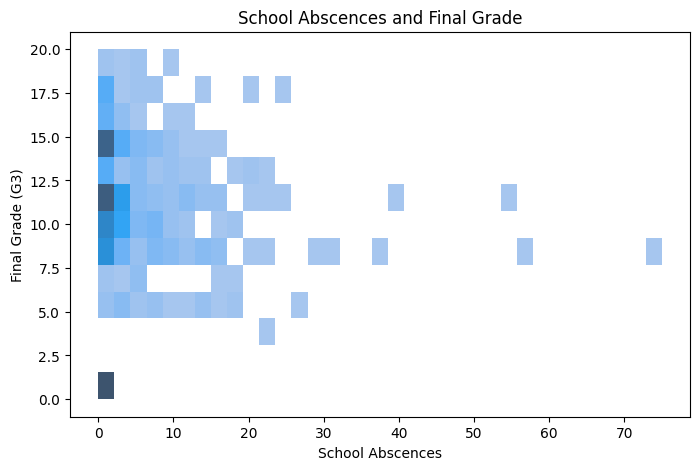

In [24]:
# Plotting the distribution of absences
plt.figure(figsize=(8,5))

sns.histplot( 
    data=df_cleaned,
    x="absences",
    y="G3"
)

plt.title("School Abscences and Final Grade")
plt.xlabel("School Abscences")
plt.ylabel("Final Grade (G3)")

plt.show()

The students within this dataset for the most part are having 8 or fewer absences as we see from the 75th percentile, with the median of 4 absences. The distribution is positively skewed from students with greater absences, with a visual inspection showing much varitaion in final grade reults at similar levels of absence. Testing will be needed to truly see any association exists.

We will now move onto the testing.

---